# Preparation

In [ ]:
!wget https://challenge.ey.com/api/v1/storage/admin-files/556750475068843-678f9918ed9624f63ca75b56-Dataset.zip
!unzip 556750475068843-678f9918ed9624f63ca75b56-Dataset.zip
!rm 556750475068843-678f9918ed9624f63ca75b56-Dataset.zip
!mv "/content/Dataset/Training_data_uhi_index.csv" Training_data_uhi_index.csv
!mv "/content/Dataset/Submission_template.csv" Submission_template.csv

--2025-03-22 04:51:00--  https://challenge.ey.com/api/v1/storage/admin-files/556750475068843-678f9918ed9624f63ca75b56-Dataset.zip
Resolving challenge.ey.com (challenge.ey.com)... 52.236.158.32
Connecting to challenge.ey.com (challenge.ey.com)|52.236.158.32|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13861358 (13M) [application/octet-stream]
Saving to: ‘556750475068843-678f9918ed9624f63ca75b56-Dataset.zip’

556750475068843-678 100%[===================>]  13.22M  7.01MB/s    in 1.9s    

2025-03-22 04:51:03 (7.01 MB/s) - ‘556750475068843-678f9918ed9624f63ca75b56-Dataset.zip’ saved [13861358/13861358]

Archive:  556750475068843-678f9918ed9624f63ca75b56-Dataset.zip
   creating: Dataset/
  inflating: Dataset/2025 EY Open Science AI Data Challenge Participant Guidance.pdf  
  inflating: Dataset/Building_Footprint.kml  
  inflating: Dataset/Landsat_LST.ipynb  
  inflating: Dataset/NY_Mesonet_Weather.xlsx  
  inflating: Dataset/Sentinel2_GeoTIFF.ipynb  
  inflatin

In [ ]:
!python -m pip install \
    "xarray[complete]" \
    rioxarray \
    rasterio \
    stackstac \
    pystac_client \
    pystac==1.11.0 \
    planetary_computer \
    odc-stac==0.3.10 \
    osmnx \
    pykml \
    geopandas \
    shapely \
    fiona \
    pvlib \
    zarr \
    adlfs \
    metpy \
    --quiet
# Supress Warnings

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.3/81.3 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.8/48.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.2/89.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.1/41.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3

In [ ]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import planetary_computer
import pystac_client
import rasterio
import xarray as xr
from odc.stac import stac_load
from rich import print
from rich.table import Table
from tqdm import tqdm

pd.set_option("display.max_colwidth", None)
warnings.filterwarnings("ignore")

In [ ]:
time_window = "2021-06-01/2021-07-24"
time_window

'2021-06-01/2021-07-24'

In [ ]:
lower_left = (40.75, -74.01)  # (long, lat)
upper_right = (40.88, -73.86)

In [ ]:
# bounds = (min_lon, min_lat, max_lon, max_lat)
bounds = (lower_left[1], lower_left[0], upper_right[1], upper_right[0])
print(bounds)

(-74.01, 40.75, -73.86, 40.88)

# Spectral data

## Landsat Data
TODO: Revisi Scale sesuai POSSIBLE 1

In [ ]:
class SatelliteData:
    def __init__(
        self,
        bounds: tuple = None,
        time_window: str = None,
        collections: str = None,
        query_params: dict = None,
        resolution: int = 10,
        degrees_per_pixel: float = 111320.0,
        crs: str = "EPSG:4326",
    ) -> None:
        self.stac = pystac_client.Client.open(
            "https://planetarycomputer.microsoft.com/api/stac/v1"
        )
        search = self.stac.search(
            bbox=bounds,
            datetime=time_window,
            collections=collections,
            query=query_params,
        )
        self.crs = crs
        self.bounds = bounds
        self.time_window = time_window
        self.collections = collections
        self.query_params = query_params
        self.items = list(search.get_items())
        self.resolution = resolution
        self.scale = resolution / degrees_per_pixel
        if self.__len__() == 0:
            raise ValueError(
                "Your search returned 0 result! Check again your parameters!"
            )
        # print(self)
        return

    def __len__(self) -> int:
        return len(self.items)

    def show_assets(self) -> pd.DataFrame:
        self.items[0].assets.items()
        assets_df = dict()

        for asset_key, asset in self.items[0].assets.items():
            assets_df[asset_key] = [asset.title]

        asset_metadata = pd.DataFrame(assets_df, index=["description"]).T.reset_index()
        asset_metadata.rename(columns={"index": "asset"}, inplace=True)
        return asset_metadata

    def load_bands(self, bands: list[str]) -> xr.core.dataset.Dataset:
        return stac_load(
            self.items,
            bands=bands,
            crs=self.crs,
            resolution=self.scale,  # Degrees
            chunks={"x": 2048, "y": 2048},
            dtype="int32",
            patch_url=planetary_computer.sign,
            bbox=self.bounds,
        )

    def __str__(self) -> str:
        table = Table(title=self.collections.upper())
        table.add_column("Attribute", justify="left", style="white", no_wrap=True)
        table.add_column("Value", style="white")
        table.add_row("Items Found", str(self.__len__()))
        table.add_row("Bounds", str(self.bounds))
        table.add_row("Time Window", self.time_window)
        table.add_row("Resolution", f"{self.resolution} meter(s) per pixel")
        table.add_row("Scale", f"{self.scale}")
        table.add_row("CRS", self.crs)
        print(table)
        return ""

    def __repr__(self) -> str:
        return self.__str__()


def plot_image(item_name, cmap, vmin=0.0, vmax=1.0):
    fig, ax = plt.subplots(figsize=(10, 10))
    exec(f"{item_name}.plot.imshow(vmin={vmin}, vmax={vmax}, cmap='{cmap}')")
    plt.title(item_name)
    plt.axis("off")
    plt.show()


def export_to_tif(
    item, output_name, lower_left, upper_right, crs="epsg:4326", count=None
):
    # Creating Dir if not exists
    path = Path(output_name)
    path.resolve().parents[0].mkdir(parents=True, exist_ok=True)

    height = item.sizes["latitude"]
    width = item.sizes["longitude"]
    gt = rasterio.transform.from_bounds(
        lower_left[1], lower_left[0], upper_right[1], upper_right[0], width, height
    )
    item.rio.write_crs(crs, inplace=True)
    item.rio.write_transform(transform=gt, inplace=True)

    with rasterio.open(
        output_name,
        "w",
        driver="GTiff",
        width=width,
        height=height,
        crs=crs,
        transform=gt,
        count=count,
        compress="lzw",
        dtype="float64",
    ) as dst:
        if hasattr(item, "to_dataarray"):
            dst.write(item.to_dataarray())
            return

        if len(item.shape) == 2:
            dst.write(item.values.reshape(1, height, width))
            return

        else:
            dst.write(item)
            return

In [ ]:
landsatc2l2 = SatelliteData(
    bounds=bounds,
    time_window=time_window,
    collections="landsat-c2-l2",
    query_params={"eo:cloud_cover": {"lt": 30}, "platform": {"in": ["landsat-8"]}},
)

landsatc2l2_assets = landsatc2l2.show_assets()
landsatc2l2_assets

,asset,description
0,qa,Surface Temperature Quality Assessment Band
1,ang,Angle Coefficients File
2,red,Red Band
3,blue,Blue Band
4,drad,Downwelled Radiance Band
5,emis,Emissivity Band
6,emsd,Emissivity Standard Deviation Band
7,trad,Thermal Radiance Band
8,urad,Upwelled Radiance Band
9,atran,Atmospheric Transmittance Band


In [ ]:
landsatc2l2

                 LANDSAT-C2-L2                  
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Attribute   ┃ Value                          ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Items Found │ 5                              │
│ Bounds      │ (-74.01, 40.75, -73.86, 40.88) │
│ Time Window │ 2021-06-01/2021-07-24          │
│ Resolution  │ 10 meter(s) per pixel          │
│ Scale       │ 8.983111749910169e-05          │
│ CRS         │ EPSG:4326                      │
└─────────────┴────────────────────────────────┘

In [ ]:
landsatc2l2.items[0].assets["lwir11"]

<Asset href=https://landsateuwest.blob.core.windows.net/landsat-c2/level-2/standard/oli-tirs/2021/014/032/LC08_L2SP_014032_20210623_20210630_02_T1/LC08_L2SP_014032_20210623_20210630_02_T1_ST_B10.TIF>

In [ ]:
display(landsatc2l2_assets)

,asset,description
0,qa,Surface Temperature Quality Assessment Band
1,ang,Angle Coefficients File
2,red,Red Band
3,blue,Blue Band
4,drad,Downwelled Radiance Band
5,emis,Emissivity Band
6,emsd,Emissivity Standard Deviation Band
7,trad,Thermal Radiance Band
8,urad,Upwelled Radiance Band
9,atran,Atmospheric Transmittance Band


In [ ]:
landsatc2l2_non_lwir_bands = [
    "red",
    "green",
    "blue",
    "qa",
    "drad",
    "emis",
    "emsd",
    "trad",
    "urad",
    "atran",
    "cdist",
    "nir08",
    "qa_radsat",
    "qa_aerosol",
]
landsatc2l2_non_lwir = landsatc2l2.load_bands(landsatc2l2_non_lwir_bands)
lwir_only = landsatc2l2.load_bands(["lwir11"])

In [ ]:
display(landsatc2l2_non_lwir)
display(lwir_only)

<xarray.Dataset> Size: 678MB
Dimensions:      (latitude: 1448, longitude: 1671, time: 5)
Coordinates:
  * latitude     (latitude) float64 12kB 40.88 40.88 40.88 ... 40.75 40.75 40.75
  * longitude    (longitude) float64 13kB -74.01 -74.01 -74.01 ... -73.86 -73.86
    spatial_ref  int32 4B 4326
  * time         (time) datetime64[ns] 40B 2021-06-07T15:39:15.904901 ... 202...
Data variables: (12/14)
    red          (time, latitude, longitude) int32 48MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    green        (time, latitude, longitude) int32 48MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    blue         (time, latitude, longitude) int32 48MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    qa           (time, latitude, longitude) int32 48MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    drad         (time, latitude, longitude) int32 48MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    emis         (time, latitude, longitude) int32 48MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    ...           ...
    urad         (time, latitude, longitude) int32 48MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    atran        (time, latitude, longitude) int32 48MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    cdist        (time, latitude, longitude) int32 48MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    nir08        (time, latitude, longitude) int32 48MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    qa_radsat    (time, latitude, longitude) int32 48MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    qa_aerosol   (time, latitude, longitude) int32 48MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>

<xarray.Dataset> Size: 48MB
Dimensions:      (latitude: 1448, longitude: 1671, time: 5)
Coordinates:
  * latitude     (latitude) float64 12kB 40.88 40.88 40.88 ... 40.75 40.75 40.75
  * longitude    (longitude) float64 13kB -74.01 -74.01 -74.01 ... -73.86 -73.86
    spatial_ref  int32 4B 4326
  * time         (time) datetime64[ns] 40B 2021-06-07T15:39:15.904901 ... 202...
Data variables:
    lwir11       (time, latitude, longitude) int32 48MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>

In [ ]:
landsatc2l2_non_lwir = landsatc2l2_non_lwir.astype(np.float64) * 0.0000275 - 0.2
lwir_only = lwir_only.astype(float) * 0.00341802 - 149.0 - 273.15

In [ ]:
# Persist the data in memory for faster operations
landsatc2l2_non_lwir = landsatc2l2_non_lwir.persist()
lwir_only = lwir_only.persist()

In [ ]:
median = landsatc2l2_non_lwir.median(dim="time")
mean = landsatc2l2_non_lwir.mean(dim="time")
max = landsatc2l2_non_lwir.max(dim="time")
min = landsatc2l2_non_lwir.min(dim="time")
std = landsatc2l2_non_lwir.std(dim="time")
var = landsatc2l2_non_lwir.var(dim="time")

In [ ]:
variables = list(median.variables.keys())
variables

['latitude',
 'longitude',
 'spatial_ref',
 'red',
 'green',
 'blue',
 'qa',
 'drad',
 'emis',
 'emsd',
 'trad',
 'urad',
 'atran',
 'cdist',
 'nir08',
 'qa_radsat',
 'qa_aerosol']

In [ ]:
landsat_to_export = list()

stats = ["median", "mean", "max", "min", "std", "var"]
for band in variables[3:]:
    for stat in stats:
        str_eval = f"{band}_{stat} = {stat}.{band}"
        exec(str_eval)

        str_eval = f"{band}_{stat}.name = '{band}_{stat}'"
        exec(str_eval)
        landsat_to_export.append(eval(f"{band}_{stat}"))

for stat in stats:
    exec(f"ndvi_{stat} = ({stat}.nir08 - {stat}.red) / ({stat}.nir08 + {stat}.red)")
    exec(
        f"evi_{stat} = 2.5 * (({stat}.nir08 - {stat}.red) / ({stat}.nir08 + 6 * {stat}.red - 7.5 * {stat}.blue + 1))"
    )
    exec(f'ndvi_{stat}.name = "ndvi_{stat}"')
    exec(f'evi_{stat}.name = "evi_{stat}"')
    exec(f'lwir_{stat} = lwir_only.lwir11.{stat}(dim="time")')
    exec(f'lwir_{stat}.name = "lwir_{stat}"')
    exec(f"landsat_to_export.extend([ndvi_{stat}, evi_{stat}, lwir_{stat}])")

In [ ]:
sorted(list(map(lambda x: x.name, landsat_to_export)))

['atran_max',
 'atran_mean',
 'atran_median',
 'atran_min',
 'atran_std',
 'atran_var',
 'blue_max',
 'blue_mean',
 'blue_median',
 'blue_min',
 'blue_std',
 'blue_var',
 'cdist_max',
 'cdist_mean',
 'cdist_median',
 'cdist_min',
 'cdist_std',
 'cdist_var',
 'drad_max',
 'drad_mean',
 'drad_median',
 'drad_min',
 'drad_std',
 'drad_var',
 'emis_max',
 'emis_mean',
 'emis_median',
 'emis_min',
 'emis_std',
 'emis_var',
 'emsd_max',
 'emsd_mean',
 'emsd_median',
 'emsd_min',
 'emsd_std',
 'emsd_var',
 'evi_max',
 'evi_mean',
 'evi_median',
 'evi_min',
 'evi_std',
 'evi_var',
 'green_max',
 'green_mean',
 'green_median',
 'green_min',
 'green_std',
 'green_var',
 'lwir_max',
 'lwir_mean',
 'lwir_median',
 'lwir_min',
 'lwir_std',
 'lwir_var',
 'ndvi_max',
 'ndvi_mean',
 'ndvi_median',
 'ndvi_min',
 'ndvi_std',
 'ndvi_var',
 'nir08_max',
 'nir08_mean',
 'nir08_median',
 'nir08_min',
 'nir08_std',
 'nir08_var',
 'qa_aerosol_max',
 'qa_aerosol_mean',
 'qa_aerosol_median',
 'qa_aerosol_min',


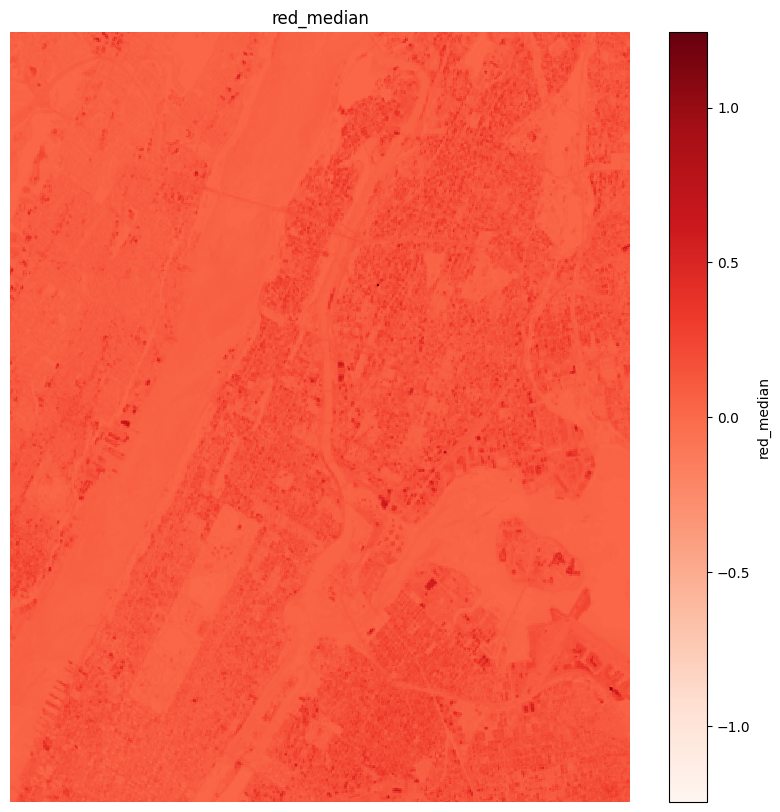

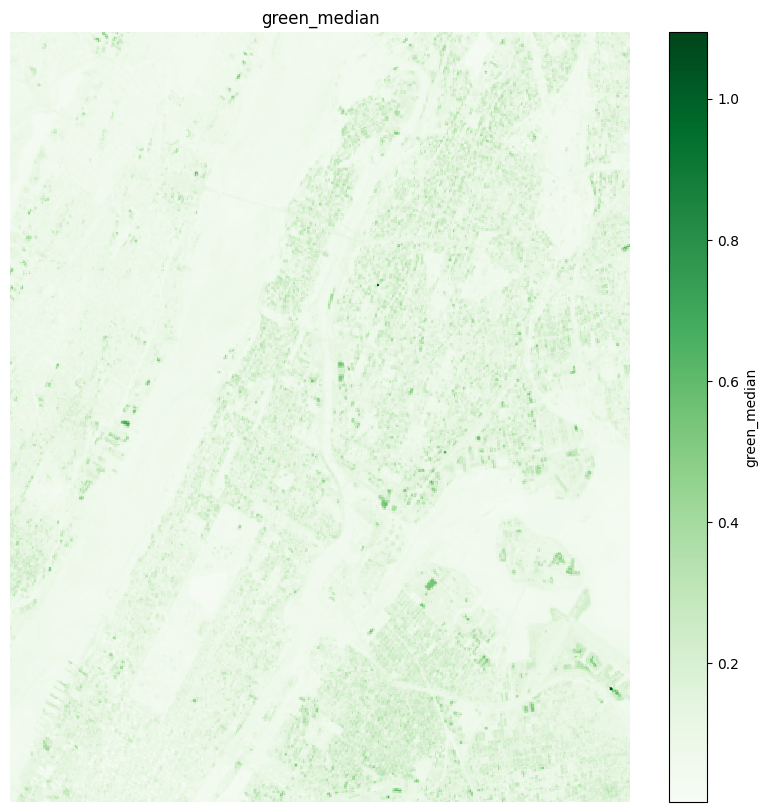

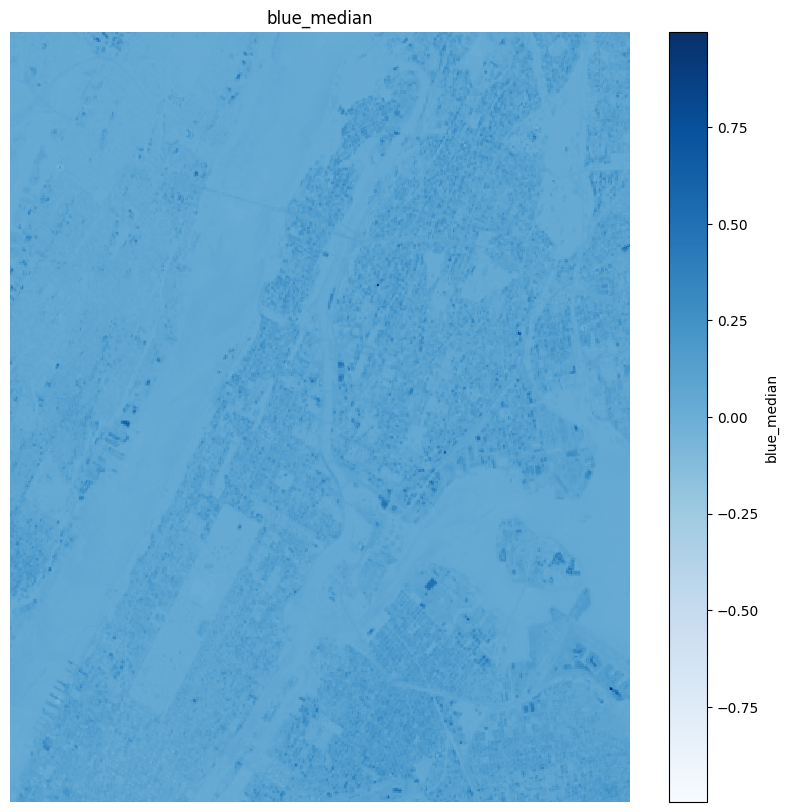

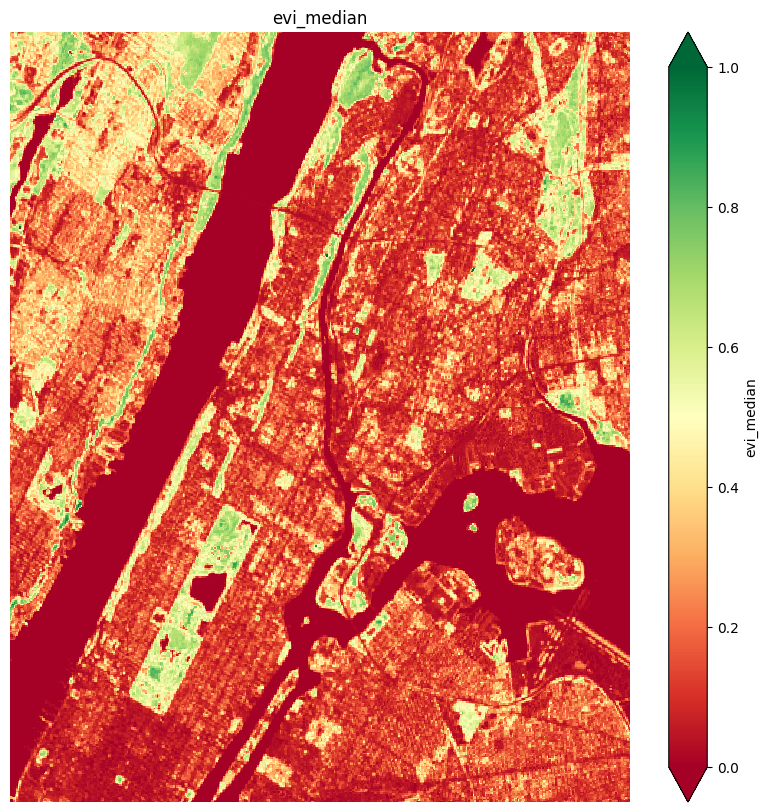

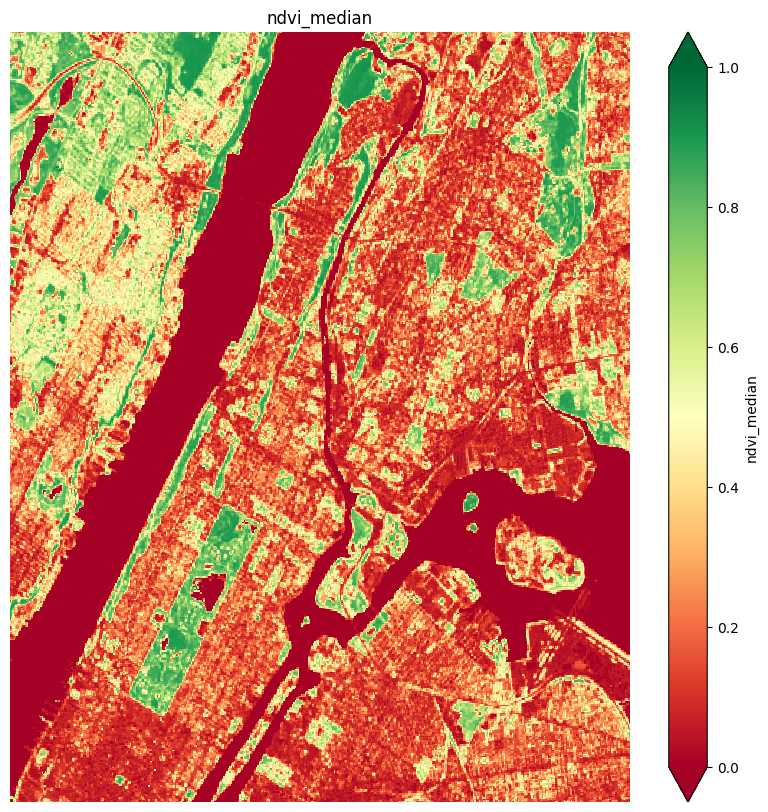

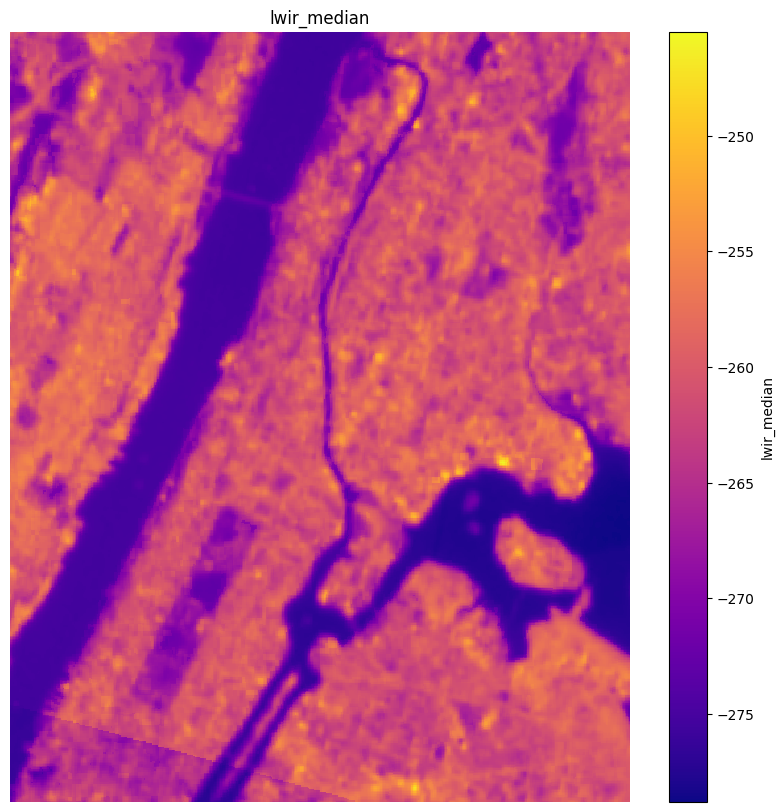

In [ ]:
plot_image("red_median", "Reds", None, None)
plot_image("green_median", "Greens", None, None)
plot_image("blue_median", "Blues", None, None)
plot_image("evi_median", "RdYlGn", vmin=0.0, vmax=1.0)
plot_image("ndvi_median", "RdYlGn")
plot_image("lwir_median", "plasma", None, None)

In [ ]:
for data in tqdm(landsat_to_export):
    filename = f"Train/{data.name}.tiff"
    export_to_tif(data, filename, lower_left, upper_right, count=1)

100%|██████████| 102/102 [02:17<00:00,  1.35s/it]


## Sentinel 2 L2a Data

In [ ]:
sentinel2l2a = SatelliteData(
    bounds=bounds,
    time_window=time_window,
    collections="sentinel-2-l2a",
    query_params={"eo:cloud_cover": {"lt": 30}},
)
sentinel2l2a

                 SENTINEL-2-L2A                 
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Attribute   ┃ Value                          ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Items Found │ 8                              │
│ Bounds      │ (-74.01, 40.75, -73.86, 40.88) │
│ Time Window │ 2021-06-01/2021-07-24          │
│ Resolution  │ 10 meter(s) per pixel          │
│ Scale       │ 8.983111749910169e-05          │
│ CRS         │ EPSG:4326                      │
└─────────────┴────────────────────────────────┘

In [ ]:
sentinel2l2a_assets = sentinel2l2a.show_assets()
sentinel2l2a_assets

,asset,description
0,AOT,Aerosol optical thickness (AOT)
1,B01,Band 1 - Coastal aerosol - 60m
2,B02,Band 2 - Blue - 10m
3,B03,Band 3 - Green - 10m
4,B04,Band 4 - Red - 10m
5,B05,Band 5 - Vegetation red edge 1 - 20m
6,B06,Band 6 - Vegetation red edge 2 - 20m
7,B07,Band 7 - Vegetation red edge 3 - 20m
8,B08,Band 8 - NIR - 10m
9,B09,Band 9 - Water vapor - 60m


No scaling required

In [ ]:
bands = [
    "B01",
    "B02",
    "B03",
    "B04",
    "B05",
    "B06",
    "B07",
    "B08",
    "B8A",
    "B11",
    "B12",
    "AOT",
    "SCL",
    "WVP",
]
data = sentinel2l2a.load_bands(bands).persist()

In [ ]:
display(data)

<xarray.Dataset> Size: 1GB
Dimensions:      (latitude: 1448, longitude: 1671, time: 8)
Coordinates:
  * latitude     (latitude) float64 12kB 40.88 40.88 40.88 ... 40.75 40.75 40.75
  * longitude    (longitude) float64 13kB -74.01 -74.01 -74.01 ... -73.86 -73.86
    spatial_ref  int32 4B 4326
  * time         (time) datetime64[ns] 64B 2021-06-06T15:38:09.024000 ... 202...
Data variables: (12/14)
    B01          (time, latitude, longitude) int32 77MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    B02          (time, latitude, longitude) int32 77MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    B03          (time, latitude, longitude) int32 77MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    B04          (time, latitude, longitude) int32 77MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    B05          (time, latitude, longitude) int32 77MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    B06          (time, latitude, longitude) int32 77MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    ...           ...
    B8A          (time, latitude, longitude) int32 77MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    B11          (time, latitude, longitude) int32 77MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    B12          (time, latitude, longitude) int32 77MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    AOT          (time, latitude, longitude) int32 77MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    SCL          (time, latitude, longitude) int32 77MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    WVP          (time, latitude, longitude) int32 77MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>

In [ ]:
median = data.median(dim="time")
mean = data.mean(dim="time")
max = data.max(dim="time")
min = data.min(dim="time")
std = data.std(dim="time")
var = data.var(dim="time")

In [ ]:
variables = list(median.variables.keys())
variables

['latitude',
 'longitude',
 'spatial_ref',
 'B01',
 'B02',
 'B03',
 'B04',
 'B05',
 'B06',
 'B07',
 'B08',
 'B8A',
 'B11',
 'B12',
 'AOT',
 'SCL',
 'WVP']

In [ ]:
stats = ["median", "mean", "max", "min", "std", "var"]
sentinel_to_export = list()

for stat in stats:
    exec(f"ndbi_{stat} = ({stat}.B11-{stat}.B08) / ({stat}.B11+{stat}.B08)")
    exec(f"ndmi_{stat} = ({stat}.B08-{stat}.B11) / ({stat}.B08+{stat}.B11)")
    exec(f"ndwi_{stat} = ({stat}.B03-{stat}.B08) / ({stat}.B03+{stat}.B08)")
    exec(f"coast_aerosol_{stat} = {stat}.B01 # = Coastal Aerosol = 60m")
    exec(f"swir16_{stat} = {stat}.B11 # = SWIR (1.6 um) = 20m")
    exec(f"swir22_{stat} = {stat}.B12 # = SWIR (2.2 um) = 20m")
    exec(f"scl_{stat} = {stat}.SCL # = Scene Classification")
    exec(f"wvp_{stat} = {stat}.WVP / 1000 # Watervapor * scale factor")
    exec(f"mndwi_{stat} = ({stat}.B03-{stat}.B11) / ({stat}.B03+{stat}.B11)")
    exec(f"""
bands = [
    f"ndbi_{stat}",
    f"ndmi_{stat}",
    f"ndwi_{stat}",
    f"coast_aerosol_{stat}",
    f"swir16_{stat}",
    f"swir22_{stat}",
    f"scl_{stat}",
    f"wvp_{stat}",
    f"mndwi_{stat}",
]
    """)

    for band in bands:
        str_eval = f"{band}.name = '{band}'"
        exec(str_eval)
        sentinel_to_export.append(eval(f"{band}"))

In [ ]:
sorted(list(map(lambda x: x.name, sentinel_to_export)))

['coast_aerosol_max',
 'coast_aerosol_mean',
 'coast_aerosol_median',
 'coast_aerosol_min',
 'coast_aerosol_std',
 'coast_aerosol_var',
 'mndwi_max',
 'mndwi_mean',
 'mndwi_median',
 'mndwi_min',
 'mndwi_std',
 'mndwi_var',
 'ndbi_max',
 'ndbi_mean',
 'ndbi_median',
 'ndbi_min',
 'ndbi_std',
 'ndbi_var',
 'ndmi_max',
 'ndmi_mean',
 'ndmi_median',
 'ndmi_min',
 'ndmi_std',
 'ndmi_var',
 'ndwi_max',
 'ndwi_mean',
 'ndwi_median',
 'ndwi_min',
 'ndwi_std',
 'ndwi_var',
 'scl_max',
 'scl_mean',
 'scl_median',
 'scl_min',
 'scl_std',
 'scl_var',
 'swir16_max',
 'swir16_mean',
 'swir16_median',
 'swir16_min',
 'swir16_std',
 'swir16_var',
 'swir22_max',
 'swir22_mean',
 'swir22_median',
 'swir22_min',
 'swir22_std',
 'swir22_var',
 'wvp_max',
 'wvp_mean',
 'wvp_median',
 'wvp_min',
 'wvp_std',
 'wvp_var']

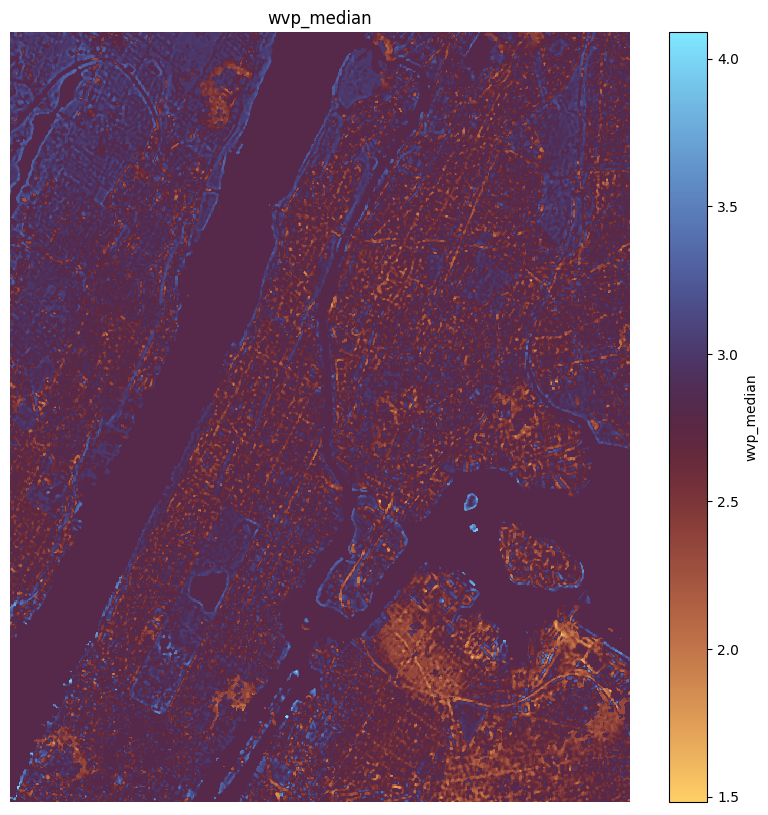

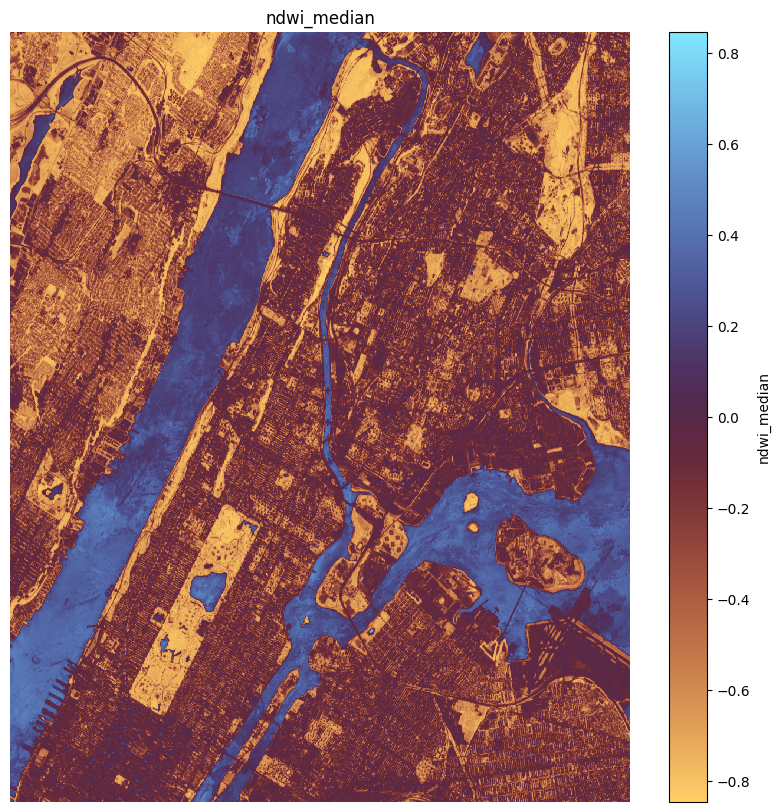

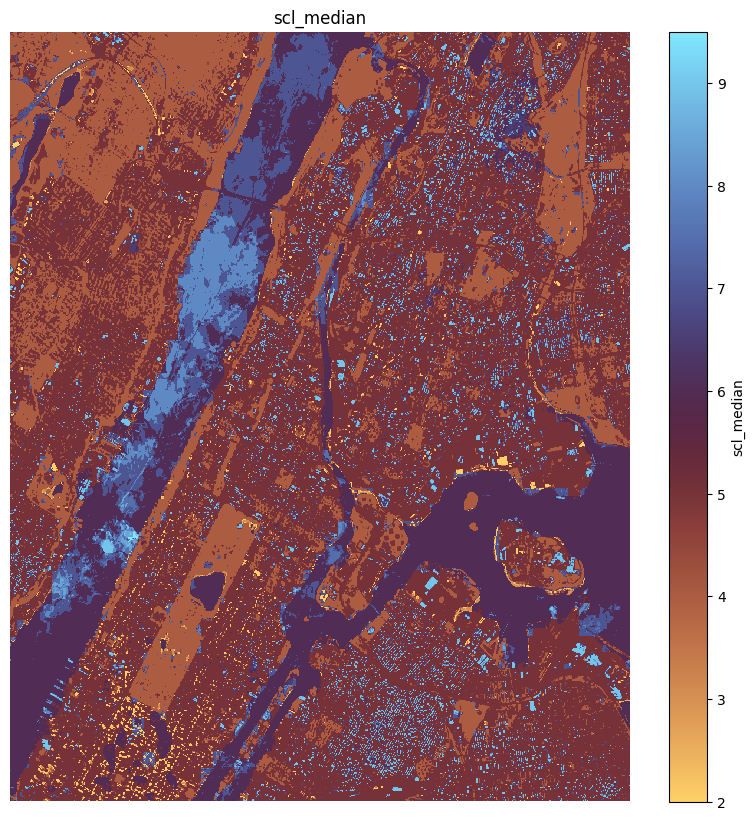

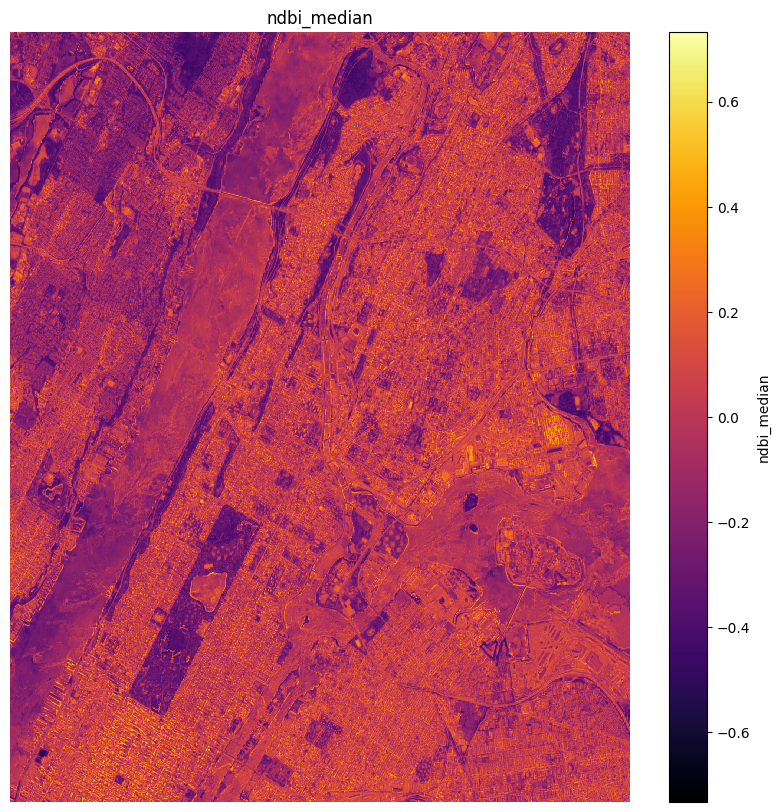

In [ ]:
plot_image("wvp_median", "managua", None, None)
plot_image("ndwi_median", "managua", None, None)
plot_image("scl_median", "managua", None, None)
plot_image("ndbi_median", "inferno", None, None)

In [ ]:
from tqdm import tqdm

tqdm.pandas()
for data in tqdm(sentinel_to_export):
    filename = f"Train/{data.name}.tiff"
    export_to_tif(data, filename, lower_left, upper_right, count=1)

100%|██████████| 54/54 [01:07<00:00,  1.25s/it]


## MODIS

In [ ]:
date_format = "%d-%m-%Y %H:%M"
df = pd.read_csv(
    "/content/Training_data_uhi_index.csv",
    parse_dates=["datetime"],
    date_format=date_format,
)
df.datetime.agg(["min", "max"])

,datetime
min,2021-07-24 15:01:00
max,2021-07-24 15:59:00


In [ ]:
time_window = "2021-06-20/2021-07-31"

In [ ]:
modis = SatelliteData(
    bounds=bounds,
    time_window=time_window,
    collections="modis-11A1-061",
    query_params={"eo:cloud_cover": {"lt": 30}},
)
modis

                 MODIS-11A1-061                 
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Attribute   ┃ Value                          ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Items Found │ 2                              │
│ Bounds      │ (-74.01, 40.75, -73.86, 40.88) │
│ Time Window │ 2021-06-20/2021-07-31          │
│ Resolution  │ 10 meter(s) per pixel          │
│ Scale       │ 8.983111749910169e-05          │
│ CRS         │ EPSG:4326                      │
└─────────────┴────────────────────────────────┘

In [ ]:
modis_assets = modis.show_assets()
modis_assets

,asset,description
0,hdf,Source data containing all bands
1,QC_Day,Quality control for daytime LST and emissivity
2,Emis_31,Band 31 emissivity
3,Emis_32,Band 32 emissivity
4,QC_Night,Quality control for nighttime LST and emissivity
5,metadata,Federal Geographic Data Committee (FGDC) Metadata
6,LST_Day_1km,Daily daytime 1km grid Land-surface Temperature
7,Clear_day_cov,Day clear-sky coverage
8,Day_view_angl,View zenith angle of daytime Landsurface Temperature
9,Day_view_time,(local solar) Time of daytime Land-surface Temperature observation


In [ ]:
bands = [
    "Emis_31",
    "Emis_32",
    "LST_Day_1km",
]
data = modis.load_bands(bands).persist()

In [ ]:
display(data)

<xarray.Dataset> Size: 58MB
Dimensions:      (latitude: 1448, longitude: 1671, time: 2)
Coordinates:
  * latitude     (latitude) float64 12kB 40.88 40.88 40.88 ... 40.75 40.75 40.75
  * longitude    (longitude) float64 13kB -74.01 -74.01 -74.01 ... -73.86 -73.86
    spatial_ref  int32 4B 4326
  * time         (time) datetime64[ns] 16B 2021-07-04 2021-07-26
Data variables:
    Emis_31      (time, latitude, longitude) int32 19MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    Emis_32      (time, latitude, longitude) int32 19MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    LST_Day_1km  (time, latitude, longitude) int32 19MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>

In [ ]:
median = data.median(dim="time")
mean = data.mean(dim="time")
max = data.max(dim="time")
min = data.min(dim="time")
std = data.std(dim="time")
var = data.var(dim="time")

In [ ]:
variables = list(data.variables.keys())
variables

['latitude',
 'longitude',
 'spatial_ref',
 'time',
 'Emis_31',
 'Emis_32',
 'LST_Day_1km']

In [ ]:
modis_to_export = list()

stats = ["median", "mean", "max", "min", "std", "var"]
for band in variables[4:]:
    for stat in stats:
        str_eval = f"{band}_{stat} = {stat}.{band}"
        exec(str_eval)

        str_eval = f"{band}_{stat}.name = '{band}_{stat}'"
        exec(str_eval)
        modis_to_export.append(eval(f"{band}_{stat}"))

In [ ]:
sorted(list(map(lambda x: x.name, modis_to_export)))

['Emis_31_max',
 'Emis_31_mean',
 'Emis_31_median',
 'Emis_31_min',
 'Emis_31_std',
 'Emis_31_var',
 'Emis_32_max',
 'Emis_32_mean',
 'Emis_32_median',
 'Emis_32_min',
 'Emis_32_std',
 'Emis_32_var',
 'LST_Day_1km_max',
 'LST_Day_1km_mean',
 'LST_Day_1km_median',
 'LST_Day_1km_min',
 'LST_Day_1km_std',
 'LST_Day_1km_var']

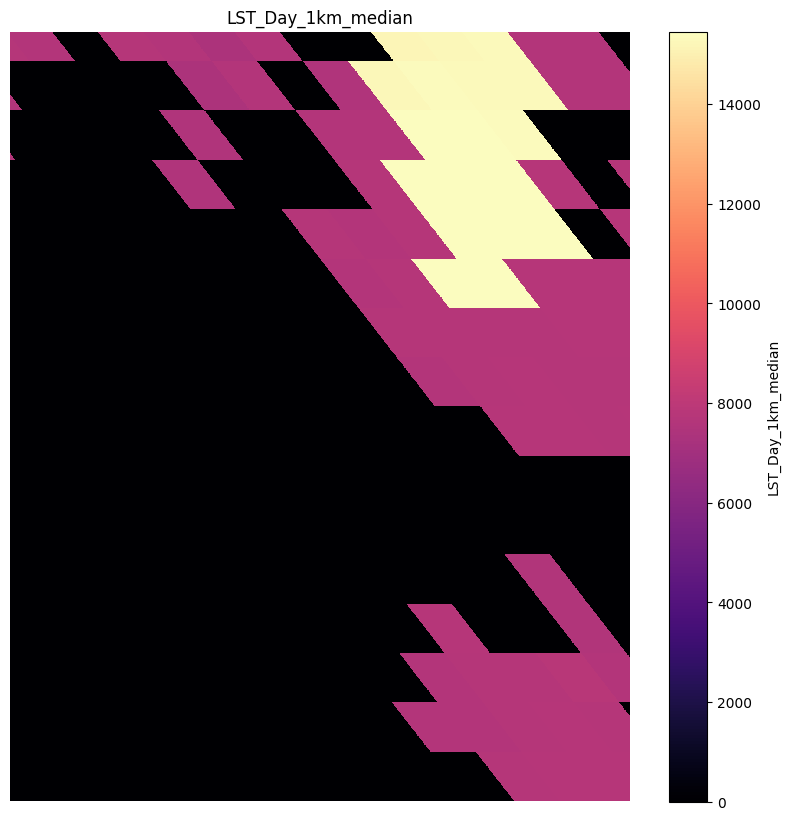

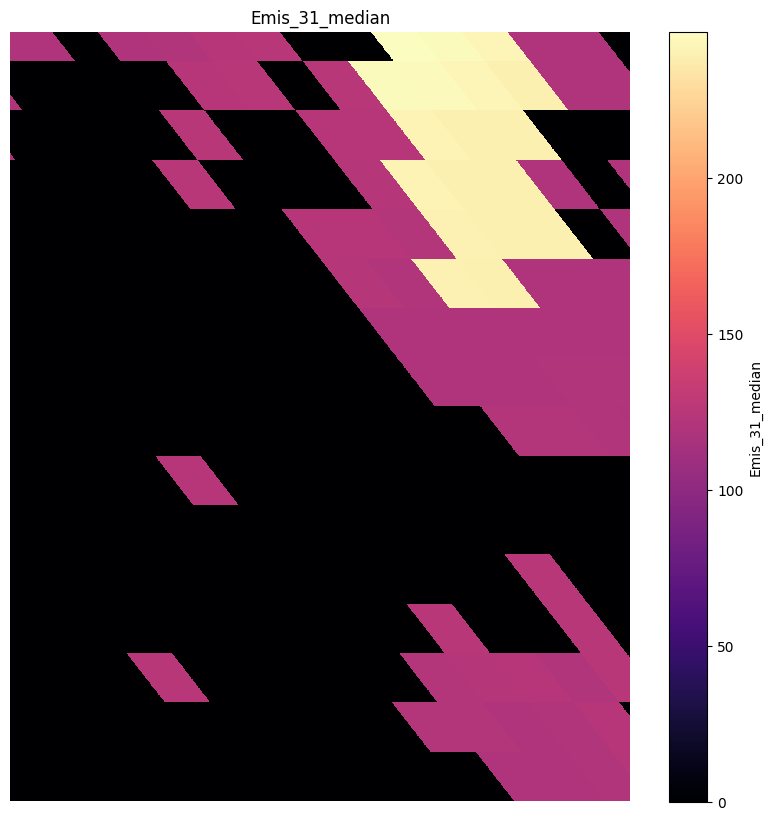

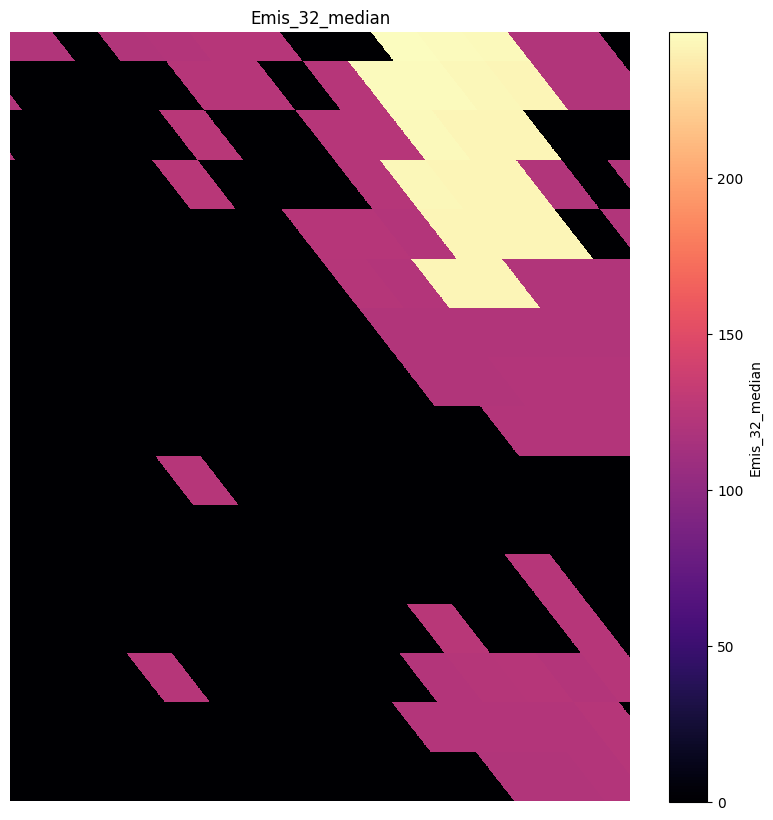

In [ ]:
plot_image("LST_Day_1km_median", "magma", None, None)
plot_image("Emis_31_median", "magma", None, None)
plot_image("Emis_32_median", "magma", None, None)

In [ ]:
from tqdm import tqdm

for data in tqdm(modis_to_export):
    filename = f"Train/{data.name}.tiff"
    export_to_tif(data, filename, lower_left, upper_right, count=1)

100%|██████████| 18/18 [00:04<00:00,  4.01it/s]


## Zip final Spectral data

In [ ]:
!zip -r TrainTIFF.zip Train/ -9

  adding: Train/ (stored 0%)
  adding: Train/atran_max.tiff (deflated 46%)
  adding: Train/LST_Day_1km_var.tiff (deflated 80%)
  adding: Train/ndbi_max.tiff (deflated 4%)
  adding: Train/blue_std.tiff (deflated 16%)
  adding: Train/Emis_32_median.tiff (deflated 83%)
  adding: Train/qa_radsat_var.tiff (deflated 98%)
  adding: Train/coast_aerosol_max.tiff (deflated 16%)
  adding: Train/trad_var.tiff (deflated 16%)
  adding: Train/qa_radsat_min.tiff (deflated 99%)
  adding: Train/emis_max.tiff (deflated 23%)
  adding: Train/ndwi_std.tiff (deflated 4%)
  adding: Train/wvp_std.tiff (deflated 10%)
  adding: Train/scl_mean.tiff (deflated 3%)
  adding: Train/swir16_max.tiff (deflated 3%)
  adding: Train/Emis_32_std.tiff (deflated 84%)
  adding: Train/nir08_median.tiff (deflated 13%)
  adding: Train/swir16_median.tiff (deflated 3%)
  adding: Train/nir08_mean.tiff (deflated 15%)
  adding: Train/qa_max.tiff (deflated 14%)
  adding: Train/green_mean.tiff (deflated 15%)
  adding: Train/lwir_median.

In [ ]:
!cp TrainTIFF.zip "/content/drive/MyDrive/EY 2025" --remove-destination
print("Done!")

Done!

# Building Features
Using proximity in KML files to get the attributes of a point

In [ ]:
import warnings

import geopandas as gpd
import numpy as np
import pandas as pd
from fiona.drvsupport import supported_drivers
from shapely.geometry import Point
from shapely.ops import unary_union
from tqdm import tqdm

warnings.filterwarnings("ignore")


def get_nearest_N_polygons(point, polygons, N):
    """Calculate the distance statistics (mean, median, min, max) to the nearest N polygons in proximity"""
    return polygons.distance(point).sort_values().head(N)


def calculate_stats_distance_to_N_polygons(row, polygons, N):
    """Calculate the distance statistics (mean, median, min, max, std, range) to the nearest N polygons in proximity"""
    point = row.geometry
    sorted_distances = get_nearest_N_polygons(point, polygons, N).values
    return (
        np.mean(sorted_distances),
        np.median(sorted_distances),
        np.max(sorted_distances),
        np.min(sorted_distances),
        np.std(sorted_distances),
        np.ptp(sorted_distances),
    )


def calculate_building_area_statistics_in_radius(
    row, polygons, buffer_radius
):  # and area density
    """Calculate building area statistics and density in an radius"""
    point = row.geometry
    buffer_zone = point.buffer(buffer_radius)
    nearby_buildings = polygons[polygons.intersects(buffer_zone)]
    count_buildings = len(nearby_buildings)
    density = len(nearby_buildings) / buffer_zone.area
    building_area = nearby_buildings.geometry.area.sum()
    return (
        density,
        building_area / buffer_zone.area,
        count_buildings,
        # Area
        np.mean(nearby_buildings.geometry.area),
        np.median(nearby_buildings.geometry.area),
        np.max(nearby_buildings.geometry.area),
        np.min(nearby_buildings.geometry.area),
        np.std(nearby_buildings.geometry.area),
        np.ptp(nearby_buildings.geometry.area),
        # Circumference
        np.mean(nearby_buildings.geometry.length),
        np.median(nearby_buildings.geometry.length),
        np.max(nearby_buildings.geometry.length),
        np.min(nearby_buildings.geometry.length),
        np.std(nearby_buildings.geometry.length),
        np.ptp(nearby_buildings.geometry.length),
    )


def calculate_nearest_building_statistics(row, polygons):
    """Calculate the area of the nearest building polygon to the point."""
    point = row.geometry
    nearest_index = get_nearest_N_polygons(point, polygons, 1).index
    nearest_polygon = polygons.iloc[nearest_index]
    neighbors = polygons[polygons.intersects(nearest_polygon)]
    intersection_area = nearest_polygon.intersection(unary_union(neighbors)).area
    centroid = nearest_polygon.centroid
    angle = np.arctan2(centroid.y - point.y, centroid.x - point.x).values[0]
    vertices = np.array(
        np.array(nearest_polygon.values[0].geoms[0].exterior.coords.xy[0]).shape[0]
    )
    return (
        nearest_polygon.area.values[0],
        intersection_area.values[0],
        np.degrees(angle),
        vertices,
    )


def calculate_point_relative_position_to_building_boundary(row, polygons):
    """
    Determine if the point is closer to the edge, center, or corners of the building polygon.
    Return boundary_distance, centroid_distance, centroid_distance/boundary_distance, distance_class
    """
    point = row.geometry
    nearest_index = get_nearest_N_polygons(point, polygons, 1).index
    nearest_polygon = polygons.iloc[nearest_index]

    # Determine the relative position to the nearest polygon's boundary
    boundary_distance = point.distance(nearest_polygon.boundary).values.squeeze()
    centroid_distance = point.distance(nearest_polygon.centroid).values.squeeze()

    if boundary_distance < centroid_distance:
        return (
            boundary_distance,
            centroid_distance,
            centroid_distance / boundary_distance,
            1,
        )  # "1st (closer to edge)"
    elif boundary_distance > centroid_distance:
        return (
            boundary_distance,
            centroid_distance,
            centroid_distance / boundary_distance,
            2,
        )  # "2nd (closer to center)"
    else:
        return (
            boundary_distance,
            centroid_distance,
            centroid_distance / boundary_distance,
            3,
        )  # "3rd (equidistant)"


def calculate_N_nearest_polygon_shape_stats_complexity(row, polygons, N):
    """Calculate the average complexity of the nearest polygon's shape using the number of vertices or fractal dimension."""
    point = row.geometry
    nearest_index = get_nearest_N_polygons(point, polygons, N).index
    nearest_polygons = polygons.iloc[nearest_index].values

    vertices = np.array(
        [
            np.array(geom.exterior.coords.xy[0]).shape[0]
            for multi in nearest_polygons
            for geom in multi.geoms
        ]
    )
    avg_vertices = vertices.mean()
    median_vertices = np.median(vertices)
    max_vertices = vertices.max()
    min_vertices = vertices.min()
    std_vertices = vertices.std()
    range_vertices = max_vertices - min_vertices
    return (
        avg_vertices,
        median_vertices,
        max_vertices,
        min_vertices,
        std_vertices,
        range_vertices,
    )

In [ ]:
def get_point(row):
    return Point(row["Longitude"], row["Latitude"])


def create_building_features(
    df,
    buffer_radius=100,  # meter
    N=50,  # N buildings
):
    print("Loading footprint...")
    epsg_distance = "32633"
    epsg_read = "4326"
    supported_drivers["LIBKML"] = "rw"
    my_map = gpd.read_file("/content/Dataset/Building_Footprint.kml", driver="LIBKML")
    my_map.to_crs(epsg=epsg_distance, inplace=True)

    print("Creating points...")
    geometric_points = df.apply(get_point, axis=1).to_numpy().tolist()
    geo_locations = gpd.GeoDataFrame(
        df, crs=f"epsg:{epsg_read}", geometry=geometric_points
    )
    geo_locations.to_crs(epsg=epsg_distance, inplace=True)
    polygons = my_map.geometry

    print("Adding 'is_building'...")
    is_building = list()
    for i in range(0, len(geo_locations)):
        point = geo_locations.geometry.loc[i]
        check = any(my_map.contains(point).values)
        is_building.append(check)
    geo_locations["is_a_building"] = list(map(int, is_building))

    print("Calculating nearest bulding distance...")
    assert geo_locations.crs == my_map.crs, "CRS must match!"
    geo_locations["nearest_building_distance"] = geo_locations.apply(
        lambda row: my_map.distance(row.geometry).min(), axis=1
    )

    print("Calculating 'stats_distance'...")
    (
        geo_locations["average_distance"],
        geo_locations["median_distance"],
        geo_locations["max_distance"],
        geo_locations["min_distance"],
        geo_locations["std_distance"],
        geo_locations["range_distance"],
    ) = zip(
        *geo_locations.apply(
            calculate_stats_distance_to_N_polygons, axis=1, polygons=polygons, N=N
        )
    )

    print("Calculating 'building stats in a radius'...")
    (
        geo_locations[f"count_{buffer_radius}radius_density"],
        geo_locations[f"area_{buffer_radius}radius_density"],
        geo_locations[f"count_bldng_{buffer_radius}radius"],
        geo_locations[f"average_bldng_{buffer_radius}radius_area"],
        geo_locations[f"median_bldng_{buffer_radius}radius_area"],
        geo_locations[f"max_bldng_{buffer_radius}radius_area"],
        geo_locations[f"min_bldng_{buffer_radius}radius_area"],
        geo_locations[f"std_bldng_{buffer_radius}radius_area"],
        geo_locations[f"range_bldng_{buffer_radius}radius_area"],
        geo_locations[f"average_bldng_{buffer_radius}radius_circumference"],
        geo_locations[f"median_bldng_{buffer_radius}radius_circumference"],
        geo_locations[f"max_bldng_{buffer_radius}radius_circumference"],
        geo_locations[f"min_bldng_{buffer_radius}radius_circumference"],
        geo_locations[f"std_bldng_{buffer_radius}radius_circumference"],
        geo_locations[f"range_bldng_{buffer_radius}radius_circumference"],
    ) = zip(
        *geo_locations.apply(
            calculate_building_area_statistics_in_radius,
            axis=1,
            polygons=polygons,
            buffer_radius=buffer_radius,
        )
    )

    print("Calculating 'nearest building stats'...")
    (
        geo_locations["nearest_bldg_area"],
        geo_locations["nearest_bldg_intersection_area"],
        geo_locations["nearest_bldg_angle"],
        geo_locations["nearest_bldg_vertices"],
    ) = zip(
        *geo_locations.apply(
            calculate_nearest_building_statistics, axis=1, polygons=polygons
        )
    )

    print("Calculating 'boundary relative position'...")
    (
        geo_locations["boundary_distance"],
        geo_locations["centroid_distance"],
        geo_locations["centroid_boundary_ratio"],
        geo_locations["perimeter_class"],
    ) = zip(
        *geo_locations.apply(
            calculate_point_relative_position_to_building_boundary,
            axis=1,
            polygons=polygons,
        )
    )

    print("Calculating 'nearest building complexity'...")
    (
        geo_locations["nearest_bldg_avg_vertices"],
        geo_locations["nearest_bldg_median_vertices"],
        geo_locations["nearest_bldg_max_vertices"],
        geo_locations["nearest_bldg_min_vertices"],
        geo_locations["nearest_bldg_std_vertices"],
        geo_locations["nearest_bldg_range_vertices"],
    ) = zip(
        *geo_locations.apply(
            calculate_N_nearest_polygon_shape_stats_complexity,
            axis=1,
            polygons=polygons,
            N=N,
        )
    )
    print("Done!")
    return geo_locations

In [ ]:
buffer_radius = 100  # meter
N = 25

date_format = "%d-%m-%Y %H:%M"
df = pd.read_csv(
    "Training_data_uhi_index.csv", date_format=date_format, parse_dates=["datetime"]
)
df_building_train = create_building_features(
    df,
    buffer_radius=buffer_radius,  # meter
    N=N,  # N buildings
)
df_building_train

Loading footprint...

Creating points...

Adding 'is_building'...

Calculating nearest bulding distance...

Calculating 'stats_distance'...

...

Calculating 'nearest building stats'...

Calculating 'boundary relative position'...

Calculating 'nearest building complexity'...

Done!

,Longitude,Latitude,datetime,UHI Index,geometry,is_a_building,nearest_building_distance,average_distance,median_distance,max_distance,...,boundary_distance,centroid_distance,centroid_boundary_ratio,perimeter_class,nearest_bldg_avg_vertices,nearest_bldg_median_vertices,nearest_bldg_max_vertices,nearest_bldg_min_vertices,nearest_bldg_std_vertices,nearest_bldg_range_vertices
0,-73.909167,40.813107,2021-07-24 15:53:00,1.030289,POINT (-5804933.414 9857596.811),0,19.079136,172.477299,196.843253,263.462881,...,19.079135940634565,108.8973615586285,5.707667,1,11.24,9.0,29,5,7.049993,24
1,-73.909187,40.813045,2021-07-24 15:53:00,1.030289,POINT (-5804943.928 9857599.08),0,19.233293,171.779953,186.929605,263.464622,...,19.23329294387811,100.24834745350759,5.212230,1,11.24,9.0,29,5,7.049993,24
2,-73.909215,40.812978,2021-07-24 15:53:00,1.023798,POINT (-5804955.321 9857602.397),0,20.268009,171.509273,187.729637,262.338258,...,20.268009205591184,91.82394160494088,4.530486,1,11.80,11.0,29,5,7.244308,24
3,-73.909242,40.812908,2021-07-24 15:53:00,1.023798,POINT (-5804967.271 9857605.484),0,20.968705,171.031895,176.157138,254.213054,...,20.968704637056224,83.64911271645329,3.989236,1,11.80,11.0,29,5,7.244308,24
4,-73.909257,40.812845,2021-07-24 15:53:00,1.021634,POINT (-5804978.048 9857607.103),0,16.324876,170.365027,168.059509,262.724930,...,16.324875874885723,76.43259722297114,4.681971,1,11.80,11.0,29,5,7.244308,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11224,-73.957050,40.790333,2021-07-24 15:57:00,0.972470,POINT (-5808964.468 9863649.01),0,295.759464,556.090567,597.611936,722.710769,...,295.7594642269793,356.2331527425588,1.204469,1,15.36,13.0,32,5,8.098790,27
11225,-73.957063,40.790308,2021-07-24 15:57:00,0.972470,POINT (-5808968.75 9863650.609),0,295.705141,555.260331,600.862678,724.743331,...,295.705140562417,356.3448538946763,1.205068,1,15.36,13.0,32,5,8.098790,27
11226,-73.957093,40.790270,2021-07-24 15:57:00,0.981124,POINT (-5808975.349 9863654.291),0,294.627364,554.330960,607.005977,723.867685,...,294.62736400070037,355.51367742899316,1.206655,1,14.96,13.0,32,5,8.349754,27
11227,-73.957112,40.790253,2021-07-24 15:59:00,0.981245,POINT (-5808978.238 9863656.573),0,293.594965,554.157261,607.869829,722.394625,...,293.5949653152025,354.5869867294122,1.207742,1,14.96,13.0,32,5,8.349754,27


In [ ]:
sub_df = pd.read_csv(
    "Submission_template.csv",
)
df_building_submission = create_building_features(
    sub_df,
    buffer_radius=buffer_radius,  # meter
    N=N,  # N buildings
)

Loading footprint...
Creating points...
Adding 'is_building'...
Calculating nearest bulding distance...
Calculating 'stats_distance'...
Calculating 'building stats in a radius'...
Calculating 'nearest building stats'...
Calculating 'boundary relative position'...
Calculating 'nearest building complexity'...
Done!


In [ ]:
df_building_train.iloc[:, 5:].to_csv(
    "Train_Building_Features_Revamped.csv", index=False
)

In [ ]:
df_building_submission.iloc[:, 4:].to_csv(
    "Submission_Building_Features_Revamped.csv", index=False
)

In [ ]:
!cp Train_Building_Features_Revamped.csv "/content/drive/MyDrive/EY 2025"
!cp Submission_Building_Features_Revamped.csv "/content/drive/MyDrive/EY 2025"

# PVLIB

In [ ]:
import pandas as pd
import pvlib
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm


def get_solar_data(row):
    times, latitude, longitude = row.datetime_cnvrt, row.Latitude, row.Longitude
    solar_position = pvlib.solarposition.get_solarposition(times, latitude, longitude)
    loc = pvlib.location.Location(latitude, longitude, tz=times.tz)
    airmass = loc.get_airmass(
        times=solar_position.index,
        solar_position=solar_position[["apparent_zenith", "zenith"]],
    )
    clearsky = loc.get_clearsky(
        solar_position.index,
        solar_position=solar_position[
            ["apparent_zenith", "zenith", "apparent_elevation"]
        ],
    )

    df_solar = pd.concat(
        [
            solar_position.reset_index(drop=True),
            airmass.reset_index(drop=True),
            clearsky.reset_index(drop=True),
        ],
        axis=1,
    )
    return df_solar


date_format = "%d-%m-%Y %H:%M"
df = pd.read_csv(
    "/content/Dataset/Training_data_uhi_index.csv",
    parse_dates=["datetime"],
    date_format=date_format,
)

stats = ["mean", "median", "min", "max"]


def evaluate_model(df):
    """
    This is to check whether the solar data is significant or not as variables
    """
    result_list = list()

    for stat in tqdm(stats):
        local_container = dict()
        df_ = df.copy()
        result_dict = dict()
        exec(f"df_.datetime = df_.datetime.{stat}()")
        df_["datetime_cnvrt"] = df_.datetime.dt.tz_localize(
            "America/New_York", ambiguous="infer"
        )
        df_["datetime_cnvrt"] = df_["datetime_cnvrt"].dt.tz_convert("UTC")
        solar_data = pd.concat(
            df_.apply(get_solar_data, axis=1).to_numpy().tolist()
        ).reset_index(drop=True)
        filename = f"/content/drive/MyDrive/EY 2025/Train_SolarData{stat.title()}SinceTrainTime.csv"
        solar_data.to_csv(filename, index=False)

        X = solar_data
        y = df_["UHI Index"]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=0
        )
        et = ExtraTreesRegressor(250, random_state=0, n_jobs=-1)
        et.fit(X_train, y_train)
        result_dict["stat"] = stat
        result_dict["r2_score"] = r2_score(y_test, et.predict(X_test))

        # Submission has no datetime, so I am using the statistics of datetime in base data
        exec(f"local_container['stat_time'] = df_.datetime_cnvrt.{stat}()")
        sub_df = pd.read_csv(
            "/content/Dataset/Submission_template.csv",
        )
        sub_df["datetime_cnvrt"] = local_container["stat_time"]
        solar_data_sub = pd.concat(
            sub_df.apply(get_solar_data, axis=1).to_numpy().tolist()
        ).reset_index(drop=True)
        filename = f"/content/drive/MyDrive/EY 2025/Submission_SolarData{stat.title()}SinceTrainTime.csv"
        solar_data_sub.to_csv(filename, index=False)
        X_sub = solar_data_sub
        sub_df["UHI Index"] = et.predict(X_sub)
        filename = f"/content/SolarData{stat.title()}SinceTrainTime.csv"
        sub_df.iloc[:, :-1].to_csv(filename, index=False)
        result_list.append(result_dict)
    return pd.DataFrame(result_list)


result = evaluate_model(df)

100%|██████████| 4/4 [16:14<00:00, 243.72s/it]


In [ ]:
result

,stat,r2_score
0,mean,0.969856
1,median,0.969239
2,min,0.971129
3,max,0.970598


# Open Street Map

In [ ]:
import json
from collections import Counter
from typing import List

import pandas as pd
import requests
from tqdm import tqdm


class OSMAPIDataset:
    API_URL = "http://overpass-api.de/api/interpreter"

    def __init__(
        self,
        train_latlong: List[tuple[float, float]],
        submission_latlong: List[tuple[float, float]],
    ) -> None:
        self.api_hit_count = 0
        self.train_latlong = train_latlong
        self.submission_latlong = submission_latlong
        self.error_record = list()

    def get_osm_data(self, latlong: List[tuple[float, float]], radius: int):
        self.api_hit_count += 1
        latitude, longitude = latlong
        query = f"""
        [out:json];
        (
            node(around:{radius},{latitude},{longitude});
            way(around:{radius},{latitude},{longitude});
            relation(around:{radius},{latitude},{longitude});
        );
        out body;
        >;
        out skel qt;
        """
        response = requests.get(self.API_URL, params={"data": query})
        if response.status_code == 200:
            data = response.json()
            return data
        else:
            print(f"Error: Unable to fetch data (Status Code: {response.status_code})")
            return None

    def create_osm_json(self, typ: "train|submission", radius: int):
        output_path = Path("/content/drive/MyDrive/EY 2025/OSM")
        if typ == "train":
            latlong = list(enumerate(self.train_latlong))
            output_path = output_path / "Train"
        elif typ == "submission":
            latlong = list(enumerate(self.submission_latlong))
            output_path = output_path / "Submission"
        else:
            raise ValueError("Invalid type. Must be 'train' or 'submission'.")

        output_path.mkdir(parents=True, exist_ok=True)
        check_existing_files = [file.stem for file in output_path.glob("*.json")]

        for i, latlong in tqdm(latlong, desc=f"Querying {typ}"):
            if str(i) in check_existing_files:
                continue
            if self.api_hit_count == 10000:
                print("Today's hit has reached 10000 times!")
                break

            data = self.get_osm_data(latlong, radius)
            if data is None:
                self.error_record.append({"type": typ, "index": i})
                continue
            with open(output_path / f"{i}.json", "w") as f:
                json.dump(data["elements"], f, indent=2)
        error_counts = Counter(map(lambda d: d["type"], self.error_record))
        print("Error counts")
        print("-" * 40)
        print(error_counts)

    def __str__(self):
        error_counts = Counter(map(lambda d: d["type"], self.error_record))
        return (
            f"OSMAPIDataset(train_latlong={len(self.train_latlong)}, "
            f"submission_latlong={len(self.submission_latlong)}, "
            f"train_errors={error_counts.get('train', 0)}, "
            f"submission_errors={error_counts.get('submission', 0)})"
        )

    def __repr__(self):
        error_counts = Counter(map(lambda d: d["type"], self.error_record))
        return (
            f"OSMAPIDataset(train_latlong={len(self.train_latlong)}, "
            f"submission_latlong={len(self.submission_latlong)}, "
            f"train_errors={error_counts.get('train', 0)}, "
            f"submission_errors={error_counts.get('submission', 0)})"
        )


cols = ["Latitude", "Longitude"]
train = pd.read_csv("/content/Dataset/Training_data_uhi_index.csv", usecols=cols)[
    cols
].values.tolist()
submission = pd.read_csv("/content/Dataset/Submission_template.csv", usecols=cols)[
    cols
].values.tolist()
osm = OSMAPIDataset(train, submission)

In [ ]:
osm.create_osm_json("train", radius=50)

Querying train: 100%|██████████| 11229/11229 [00:04<00:00, 2742.58it/s]

Error counts
----------------------------------------
Counter()


In [ ]:
osm.create_osm_json("submission", radius=50)

Querying submission: 100%|██████████| 1040/1040 [00:01<00:00, 641.41it/s]

Error counts
----------------------------------------
Counter()


In [ ]:
print(osm)

OSMAPIDataset(train_latlong=11229, submission_latlong=1040, train_errors=0, submission_errors=0)


In [ ]:
train_osm = list(Path("/content/drive/MyDrive/EY 2025/OSM/Train").glob("*.json"))
train_osm[0]

PosixPath('/content/drive/MyDrive/EY 2025/OSM/Train/10229.json')

In [ ]:
# Load the JSON file
file_index = 0  # Example index, update dynamically
file_path = train_osm[file_index]

# Load the LatLong DataFrame
latlong_df = pd.read_csv(
    "/content/Training_data_uhi_index.csv"
)  # Ensure this CSV exists with index matching JSON files
latlong_df = latlong_df.loc[:, ["Longitude", "Latitude"]].rename(
    columns={"Longitude": "lon", "Latitude": "lat"}
)
latlong_df


def convert_to_point(row):
    return Point(row["lon"], row["lat"])


latlong_df["geometry"] = latlong_df.apply(convert_to_point, axis=1)
source_gdf = gpd.GeoDataFrame(latlong_df.geometry, crs="EPSG:4326").to_crs("EPSG:3857")


def row_index(row):
    return row.name


source_gdf["row_index"] = source_gdf.apply(row_index, axis=1)
source_gdf.head()

,geometry,row_index
0,POINT (-8227530.799 4984813.901),0
1,POINT (-8227533.025 4984804.83),1
2,POINT (-8227536.179 4984795.024),2
3,POINT (-8227539.148 4984784.729),3
4,POINT (-8227540.817 4984775.414),4


In [ ]:
import numpy as np

unmapped_tags = set()
no_tags = list()
error_point = list()


def map_tags(tags):
    for tag in tags:
        if tag == "highway":
            return tag + "_" + tags[tag]
        elif tag == "addr:housenumber":
            return "house"
        elif tag == "natural":
            return tag + "_" + tags[tag]
        elif tag == "amenity":
            return tag + "_" + tags[tag]
        elif tag == "barrier":
            return tag + "_" + tags[tag]
        elif tag == "bridge":
            if tags[tag] == "yes":
                return "bridge"
        elif tag == "railway":
            return tag + "_" + tags[tag]
        elif tag == "footway":
            return "footway"
        elif tag == "tourism":
            return tag + "_" + tags[tag]
        elif tag == "emergency":
            return tag + "_" + tags[tag]
        else:
            unmapped_tags.add(tag)
            continue


def extract_osm_data(row, json_files):
    df_json = pd.read_json(json_files[row.row_index])
    data = df_json[
        (df_json.tags.notnull())
        & (df_json.type != "relation")
        & (df_json.type != "way")
    ].iloc[:, 2:5]
    try:
        data["type"] = data.tags.apply(map_tags)
    except Exception as e:
        print(e)
        no_tags.append(row.row_index)
        return pd.DataFrame({"amenity_bench_count": [np.nan]})
    try:
        data["geometry"] = data.apply(convert_to_point, axis=1)
    except Exception as e:
        print(e)
        error_point.append(row.row_index)
        return pd.DataFrame({"amenity_bench_count": [np.nan]})

    gpd_json = (
        gpd.GeoDataFrame(data, crs="EPSG:4326")
        .to_crs("EPSG:3857")
        .drop(
            columns=[
                "lat",
                "lon",
                "tags",
            ]
        )
    )
    geometry_reference = row.geometry
    gpd_json["distance"] = gpd_json.geometry.distance(geometry_reference)
    group = (
        gpd_json.groupby("type")["distance"]
        .agg(["mean", "max", "min", "median", "count", "var", "std"])
        .fillna(-9)
    )
    # Flatten the grouped DataFrame
    flat_df = group.stack().to_frame().T  # Convert to single-row DataFrame
    flat_df.columns = [
        f"{col[0]}_distance_{col[1]}" if col[1] != "count" else f"{col[0]}_{col[1]}"
        for col in flat_df.columns
    ]  # Rename columns
    return flat_df


train_osm_results = source_gdf.apply(extract_osm_data, axis=1, json_files=train_osm)
train_osm_results = pd.concat(
    train_osm_results.to_numpy().tolist(), ignore_index=True
).fillna(-9)

In [ ]:
train_osm_results

,amenity_bench_distance_mean,amenity_bench_distance_max,amenity_bench_distance_min,amenity_bench_distance_median,amenity_bench_count,amenity_bench_distance_var,amenity_bench_distance_std,amenity_bicycle_parking_distance_mean,amenity_bicycle_parking_distance_max,amenity_bicycle_parking_distance_min,...,amenity_college_count,amenity_college_distance_var,amenity_college_distance_std,tourism_hotel_distance_mean,tourism_hotel_distance_max,tourism_hotel_distance_min,tourism_hotel_distance_median,tourism_hotel_count,tourism_hotel_distance_var,tourism_hotel_distance_std
0,5688.241491,5695.007322,5681.457123,5688.250759,4.0,41.357884,6.431010,5666.264349,5674.221605,5658.307093,...,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0
1,5687.301719,5694.038606,5680.545831,5687.311219,4.0,41.008859,6.403816,5665.344669,5673.298243,5657.391096,...,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0
2,5699.951668,5753.961277,5678.838882,5692.268859,7.0,646.184827,25.420166,5675.367111,5690.264376,5655.679074,...,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0
3,5698.451014,5752.412163,5677.404828,5690.769089,7.0,644.406468,25.385162,5673.863991,5688.715197,5654.239796,...,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0
4,5698.116222,5752.034009,5677.129463,5690.435116,7.0,642.821172,25.353918,5673.527065,5688.337170,5653.959845,...,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11224,-9.000000,-9.000000,-9.000000,-9.000000,-9.0,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,...,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0
11225,-9.000000,-9.000000,-9.000000,-9.000000,-9.0,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,...,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0
11226,-9.000000,-9.000000,-9.000000,-9.000000,-9.0,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,...,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0
11227,-9.000000,-9.000000,-9.000000,-9.000000,-9.0,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,...,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0


In [ ]:
train_osm_results.to_csv("/content/drive/MyDrive/EY 2025/Train_OSM.csv", index=False)

In [ ]:
no_tags = list()
error_point = list()

latlong_df = pd.read_csv("/content/Submission_template.csv")
latlong_df = latlong_df.loc[:, ["Longitude", "Latitude"]].rename(
    columns={"Longitude": "lon", "Latitude": "lat"}
)
latlong_df["geometry"] = latlong_df.apply(convert_to_point, axis=1)

source_gdf = gpd.GeoDataFrame(latlong_df.geometry, crs="EPSG:4326").to_crs("EPSG:3857")
source_gdf["row_index"] = source_gdf.apply(row_index, axis=1)

submission_osm = list(
    Path("/content/drive/MyDrive/EY 2025/OSM/Submission").glob("*.json")
)
submission_osm_results = source_gdf.apply(
    extract_osm_data, axis=1, json_files=submission_osm
)
submission_osm_results = pd.concat(
    submission_osm_results.to_numpy().tolist(), ignore_index=True
).fillna(-9)

In [ ]:
submission_osm_results

,amenity_bench_distance_mean,amenity_bench_distance_max,amenity_bench_distance_min,amenity_bench_distance_median,amenity_bench_count,amenity_bench_distance_var,amenity_bench_distance_std,railway_milestone_distance_mean,railway_milestone_distance_max,railway_milestone_distance_min,...,amenity_social_facility_count,amenity_social_facility_distance_var,amenity_social_facility_distance_std,tourism_picnic_site_distance_mean,tourism_picnic_site_distance_max,tourism_picnic_site_distance_min,tourism_picnic_site_distance_median,tourism_picnic_site_count,tourism_picnic_site_distance_var,tourism_picnic_site_distance_std
0,1807.211661,1819.148497,1795.274824,1807.211661,2.0,284.976141,16.881236,1752.912442,1755.619283,1750.2056,...,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0
1,-9.000000,-9.000000,-9.000000,-9.000000,-9.0,-9.000000,-9.000000,-9.000000,-9.000000,-9.0000,...,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0
2,-9.000000,-9.000000,-9.000000,-9.000000,-9.0,-9.000000,-9.000000,-9.000000,-9.000000,-9.0000,...,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0
3,3266.483680,3272.771241,3260.196118,3266.483680,2.0,79.066864,8.891955,-9.000000,-9.000000,-9.0000,...,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0
4,2587.043100,2587.043100,2587.043100,2587.043100,1.0,-9.000000,-9.000000,-9.000000,-9.000000,-9.0000,...,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1035,-9.000000,-9.000000,-9.000000,-9.000000,-9.0,-9.000000,-9.000000,-9.000000,-9.000000,-9.0000,...,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0
1036,-9.000000,-9.000000,-9.000000,-9.000000,-9.0,-9.000000,-9.000000,-9.000000,-9.000000,-9.0000,...,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0
1037,-9.000000,-9.000000,-9.000000,-9.000000,-9.0,-9.000000,-9.000000,-9.000000,-9.000000,-9.0000,...,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0
1038,-9.000000,-9.000000,-9.000000,-9.000000,-9.0,-9.000000,-9.000000,-9.000000,-9.000000,-9.0000,...,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0,-9.0


In [ ]:
submission_osm_results.reindex(columns=train_osm_results.columns, fill_value=-9).to_csv(
    "/content/drive/MyDrive/EY 2025/Submission_OSM.csv", index=False
)